# Modelo CNN 

## Modelo CNN MobileNetV2

### Activar GPU NVIDIA 

In [1]:
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
import torch

print(torch.__version__)               # Debe contener "cu121" o similar, NO "cpu"
print(torch.cuda.is_available())       # Debe imprimir: True
print(torch.cuda.get_device_name(0))   # Debe imprimir el nombre de tu GPU, ej: "NVIDIA GeForce RTX 3060"
device = (
    "cuda"  if torch.cuda.is_available() else
    "mps"   if torch.backends.mps.is_available() else  # Apple Silicon
    "cpu"
)
print(f"Usando dispositivo: {device}")
# Output esperado en tu caso → "Usando dispositivo: cuda"

2.5.1
True
NVIDIA GeForce RTX 4070 Laptop GPU
Usando dispositivo: cuda


### 1. Imports y configuración global

In [2]:
# ============================================================
# 1. IMPORTS Y CONFIGURACIÓN GLOBAL
# ============================================================

# --- Librerías estándar ---
import pathlib

# --- Data Science ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- PyTorch core ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- Torchvision ---
import torchvision.transforms as transforms
import torchvision.models as models

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- PIL ---
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Evitar crashes con imágenes corruptas
Image.MAX_IMAGE_PIXELS = None           # Suprimir DecompressionBombWarning

# ============================================================
# CONSTANTES GLOBALES
# ============================================================

# Rutas
# ✅ IMG_DIR apunta ahora a las imágenes ya pre-procesadas (224×224)
# El script 00_resize_images.py ya hizo el Resize(256)+CenterCrop(224)
SYNC_CSV  = pathlib.Path("../data/listingV5_PriceCapID.csv", dtype={'id': 'Int64'})
IMG_DIR   = pathlib.Path("../data/Front_Images_224/")
MODEL_DIR = pathlib.Path("../models/")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparámetros
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 500
LR          = 1e-3
RANDOM_SEED = 42

# Estadísticas de normalización ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibilidad
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Diagnóstico
print("=" * 55)
print("  SmartHost Analytics — Fase 3: CNN Visual")
print("=" * 55)
print(f"  PyTorch versión : {torch.__version__}")
print(f"  Dispositivo     : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU             : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  ⚠️  Sin GPU — el entrenamiento será más lento en CPU.")
print(f"  IMG_SIZE        : {IMG_SIZE}x{IMG_SIZE} px")
print(f"  BATCH_SIZE      : {BATCH_SIZE}")
print(f"  NUM_EPOCHS      : {NUM_EPOCHS}")
print(f"  Learning Rate   : {LR}")
print("=" * 55)

  SmartHost Analytics — Fase 3: CNN Visual
  PyTorch versión : 2.5.1
  Dispositivo     : cuda
  GPU             : NVIDIA GeForce RTX 4070 Laptop GPU
  VRAM disponible : 8.6 GB
  IMG_SIZE        : 224x224 px
  BATCH_SIZE      : 32
  NUM_EPOCHS      : 500
  Learning Rate   : 0.001


C:\Users\david\AppData\Local\Temp\ipykernel_31096\1948430365.py:38: DeprecationWarning: support for supplying keyword arguments to pathlib.PurePath is deprecated and scheduled for removal in Python 3.14
  SYNC_CSV  = pathlib.Path("../data/listingV5_PriceCapID.csv", dtype={'id': 'Int64'})


### 1.1. Sincronización Dataset

✅ CSV cargado: 5,667 filas, 32 columnas
✅ Verificación OK — los 5,667 IDs del CSV tienen imagen en disco.

📊 Estadísticas de precio:
count    5667.00
mean      111.77
std        61.67
min        18.00
25%        75.00
50%        98.00
75%       132.00
max       450.00
Name: price, dtype: float64


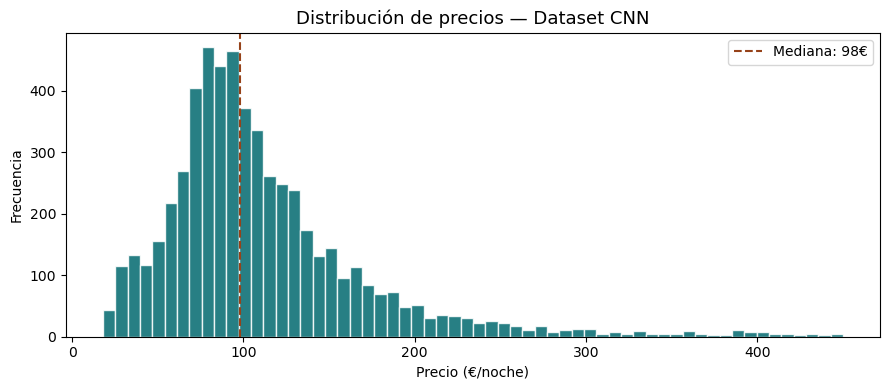

In [3]:
# ============================================================
# 1.1 — CARGA Y VERIFICACIÓN DEL CSV SINCRONIZADO
# ============================================================
# Las imágenes ya están pre-procesadas y sincronizadas con el CSV
# por el script 00_resize_images.py — no hace falta re-sincronizar.
# Solo verificamos que todo encaja antes de entrenar.

df_sync = pd.read_csv(SYNC_CSV)

print(f"✅ CSV cargado: {len(df_sync):,} filas, {len(df_sync.columns)} columnas")

# Verificación rápida: comprobar que cada ID del CSV tiene su imagen en disco
ids_csv        = set(df_sync["id"].astype(int).tolist())
# Construcción robusta del inventario de imágenes
ids_en_disco = set()
nombres_a_id = {}  # mapa: id_int → path real del archivo

for f in IMG_DIR.glob("*.jpg"):
    stem = f.stem  # ej: "12345" o "5.098e+17"
    try:
        id_int = int(float(stem))  # convierte ambos formatos al mismo int
        ids_en_disco.add(id_int)
        nombres_a_id[id_int] = f
    except ValueError:
        pass

ids_csv = set(df_sync["id"].astype("Int64").tolist())
ids_sin_imagen = ids_csv - ids_en_disco

if ids_sin_imagen:
    print(f"⚠️  AVISO: {len(ids_sin_imagen)} IDs en el CSV no tienen imagen en {IMG_DIR}")
    print(f"   Vuelve a ejecutar 00_resize_images.py para regenerarlas.")
else:
    print(f"✅ Verificación OK — los {len(ids_csv):,} IDs del CSV tienen imagen en disco.")

print(f"\n📊 Estadísticas de precio:")
print(df_sync["price"].describe().round(2))

# Distribución de precios
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_sync["price"], bins=60, color="#01696f", edgecolor="white", alpha=0.85)
ax.set_title("Distribución de precios — Dataset CNN", fontsize=13)
ax.set_xlabel("Precio (€/noche)")
ax.set_ylabel("Frecuencia")
ax.axvline(df_sync["price"].median(), color="#964219", linestyle="--",
            label=f'Mediana: {df_sync["price"].median():.0f}€')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# CELDA 1.2 — INVENTARIO DE IMÁGENES EN DISCO
# ============================================================

# Obtener todos los archivos .jpg en la carpeta de imágenes
image_files = list(IMG_DIR.glob("*.jpg")) + list(IMG_DIR.glob("*.jpeg"))

# Construir set de IDs disponibles (nombre del archivo sin extensión)
ids_disponibles = set()
for f in image_files:
    try:
        # Soporta tanto "12345.jpg" como "12345.0.jpg"
        ids_disponibles.add(int(float(f.stem)))
    except ValueError:
        pass  # Ignorar archivos con nombre no numérico

print(f"🖼️  Imágenes encontradas en disco: {len(image_files)}")
print(f"🗂️  IDs de imágenes disponibles  : {len(ids_disponibles)}")

🖼️  Imágenes encontradas en disco: 5667
🗂️  IDs de imágenes disponibles  : 5667


  RESUMEN DE SINCRONIZACIÓN
  Filas en CSV original      : 5,667
  Imágenes disponibles       : 5,667
  Filas ELIMINADAS (sin img) : 0  (0.0%)
  ✅ Filas SINCRONIZADAS     : 5,667


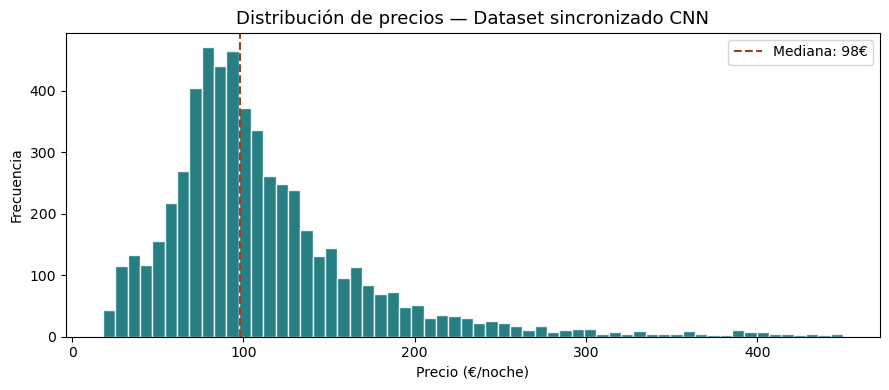


📊 Estadísticas de precio (post-filtro):
count    5667.00
mean      111.77
std        61.67
min        18.00
25%        75.00
50%        98.00
75%       132.00
max       450.00
Name: price, dtype: float64


In [5]:
# ============================================================
# CELDA 1.3 — FILTRO DE EMPAREJAMIENTO CSV ↔ IMÁGENES
# ============================================================

n_antes = len(df_sync)

# Asegura que los IDs del CSV son int limpio (sin decimales)
df_sync['id'] = df_sync['id'].astype(float).astype(int)

ids_csv = set(df_sync['id'].tolist())
ids_validos = ids_csv.intersection(ids_disponibles)

df_sync = df_sync[df_sync['id'].isin(ids_validos)].reset_index(drop=True)

n_despues = len(df_sync)
n_eliminados = n_antes - n_despues

print("=" * 50)
print("  RESUMEN DE SINCRONIZACIÓN")
print("=" * 50)
print(f"  Filas en CSV original      : {n_antes:,}")
print(f"  Imágenes disponibles       : {len(ids_disponibles):,}")
print(f"  Filas ELIMINADAS (sin img) : {n_eliminados:,}  ({n_eliminados/n_antes*100:.1f}%)")
print(f"  ✅ Filas SINCRONIZADAS     : {n_despues:,}")
print("=" * 50)

# Visualización de la distribución de precio tras el filtro
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_sync["price"], bins=60, color="#01696f", edgecolor="white", alpha=0.85)
ax.set_title("Distribución de precios — Dataset sincronizado CNN", fontsize=13)
ax.set_xlabel("Precio (€/noche)")
ax.set_ylabel("Frecuencia")
ax.axvline(df_sync["price"].median(), color="#964219", linestyle="--",
            label=f'Mediana: {df_sync["price"].median():.0f}€')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de precio (post-filtro):")
print(df_sync["price"].describe().round(2))

In [6]:
# ============================================================
# CELDA 1.4 — GUARDAR EL CSV SINCRONIZADO
# ============================================================

df_sync.to_csv(SYNC_CSV, index=False)

print(f"CSV sincronizado guardado en: {SYNC_CSV}")
print(f"   Filas: {len(df_sync):,} | Columnas: {len(df_sync.columns)}")
print(f"\n   Este CSV es la ÚNICA fuente de verdad para el DataLoader.")
print(f"   Cada fila tiene su imagen .jpg correspondiente en {IMG_DIR}")

CSV sincronizado guardado en: ..\data\listingV5_PriceCapID.csv
   Filas: 5,667 | Columnas: 32

   Este CSV es la ÚNICA fuente de verdad para el DataLoader.
   Cada fila tiene su imagen .jpg correspondiente en ..\data\Front_Images_224


### 2. DataLoader Visual

In [7]:
# ============================================================
# 2.1 — DATASET PERSONALIZADO (AirbnbImageDataset)
# ============================================================
# Las imágenes en Front_Images_224 ya son 224×224 px exactos.
# El pipeline de transforms solo necesita aplicar:
#   - RandomHorizontalFlip  (data augmentation, solo train)
#   - ToTensor              (HWC uint8 → CHW float [0,1])
#   - Normalize             (stats ImageNet)
# El costoso Resize+CenterCrop ya NO se hace aquí en tiempo de ejecución.

class AirbnbImageDataset(Dataset):

    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = pathlib.Path(img_dir)
        self.transform = transform

        # ── Construir mapa id_int → path real del archivo ──────────────
        # Los archivos pueden llamarse "12345.jpg" o "5.09e+17.jpg"
        # int(float(stem)) normaliza ambos formatos al mismo entero.
        self.nombres_a_id = {}
        for f in self.img_dir.glob("*.jpg"):
            try:
                id_int = int(float(f.stem))
                self.nombres_a_id[id_int] = f
            except ValueError:
                pass
        # ───────────────────────────────────────────────────────────────

    def __len__(self):
        return len(self.df)

    # Esta función extrae el Id y precio de la fila, carga la imagen correspondiente, aplica transformaciones y devuelve el tensor de imagen + precio
    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        id_int = int(float(row["id"]))   # ← int(float()) para IDs grandes
        precio = float(row["price"])

        img_path = self.nombres_a_id[id_int]   # usa el mapa, no f-string
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(precio, dtype=torch.float32)

print("✅ Clase AirbnbImageDataset definida.")
print(f"   Cada __getitem__ devuelve: (Tensor [3, {IMG_SIZE}, {IMG_SIZE}], precio_float)")

✅ Clase AirbnbImageDataset definida.
   Cada __getitem__ devuelve: (Tensor [3, 224, 224], precio_float)


In [8]:
# ============================================================
# 2.2 — PIPELINES DE TRANSFORMACIÓN
# ============================================================
#
#   PIPELINE TRAIN          PIPELINE VAL/TEST
#   ─────────────────────   ─────────────────────
#   1. RandomHorizontalFlip  (sin augmentation)
#   2. ToTensor              1. ToTensor
#   3. Normalize ImageNet    2. Normalize ImageNet
#
# Nota: Resize(256) y CenterCrop(224) ya fueron aplicados
# offline por 00_resize_images.py → se eliminan aquí.
# Esto hace que cada epoch sea notablemente más rápido.

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # Data Augmentation (solo train)
    transforms.ToTensor(),                   # HWC uint8 → CHW float [0,1]
    transforms.Normalize(                    # Normalizar con stats ImageNet
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])

transform_val = transforms.Compose([
    # SIN RandomHorizontalFlip → validación siempre determinista
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Pipelines de transformación definidos.")
print("\ntransform_train:")
for i, t in enumerate(transform_train.transforms):
    marker = "  ← solo train" if "Flip" in type(t).__name__ else ""
    print(f"  {i+1}. {type(t).__name__}{marker}")
print("\ntransform_val:")
for i, t in enumerate(transform_val.transforms):
    print(f"  {i+1}. {type(t).__name__}")

✅ Pipelines de transformación definidos.

transform_train:
  1. RandomHorizontalFlip  ← solo train
  2. ToTensor
  3. Normalize

transform_val:
  1. ToTensor
  2. Normalize


In [9]:
# ============================================================
# 2.3 — SPLIT TRAIN/VAL Y DATALOADERS
# ============================================================

df_train, df_val = train_test_split(
    df_sync,
    test_size=0.2,
    random_state=RANDOM_SEED
)

dataset_train = AirbnbImageDataset(df_train, IMG_DIR, transform=transform_train)
dataset_val   = AirbnbImageDataset(df_val,   IMG_DIR, transform=transform_val)

loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

loader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("=" * 50)
print("  RESUMEN DE SPLITS Y DATALOADERS")
print("=" * 50)
print(f"  Total apartamentos sync : {len(df_sync):,}")
print(f"  Train                   : {len(dataset_train):,} imágenes ({len(loader_train)} batches)")
print(f"  Val                     : {len(dataset_val):,} imágenes ({len(loader_val)} batches)")
print(f"  Batch size              : {BATCH_SIZE}")
print(f"  pin_memory              : True (GPU activa)")
print("=" * 50)

  RESUMEN DE SPLITS Y DATALOADERS
  Total apartamentos sync : 5,667
  Train                   : 4,533 imágenes (142 batches)
  Val                     : 1,134 imágenes (36 batches)
  Batch size              : 32
  pin_memory              : True (GPU activa)


📐 Shape del batch : torch.Size([32, 3, 224, 224])  → [batch, canales, alto, ancho]
💰 Precios del batch (primeros 8): [154.  61. 102.  98.  60.  25.  64.  78.] €/noche
   min=25€  |  max=305€  |  media=106€


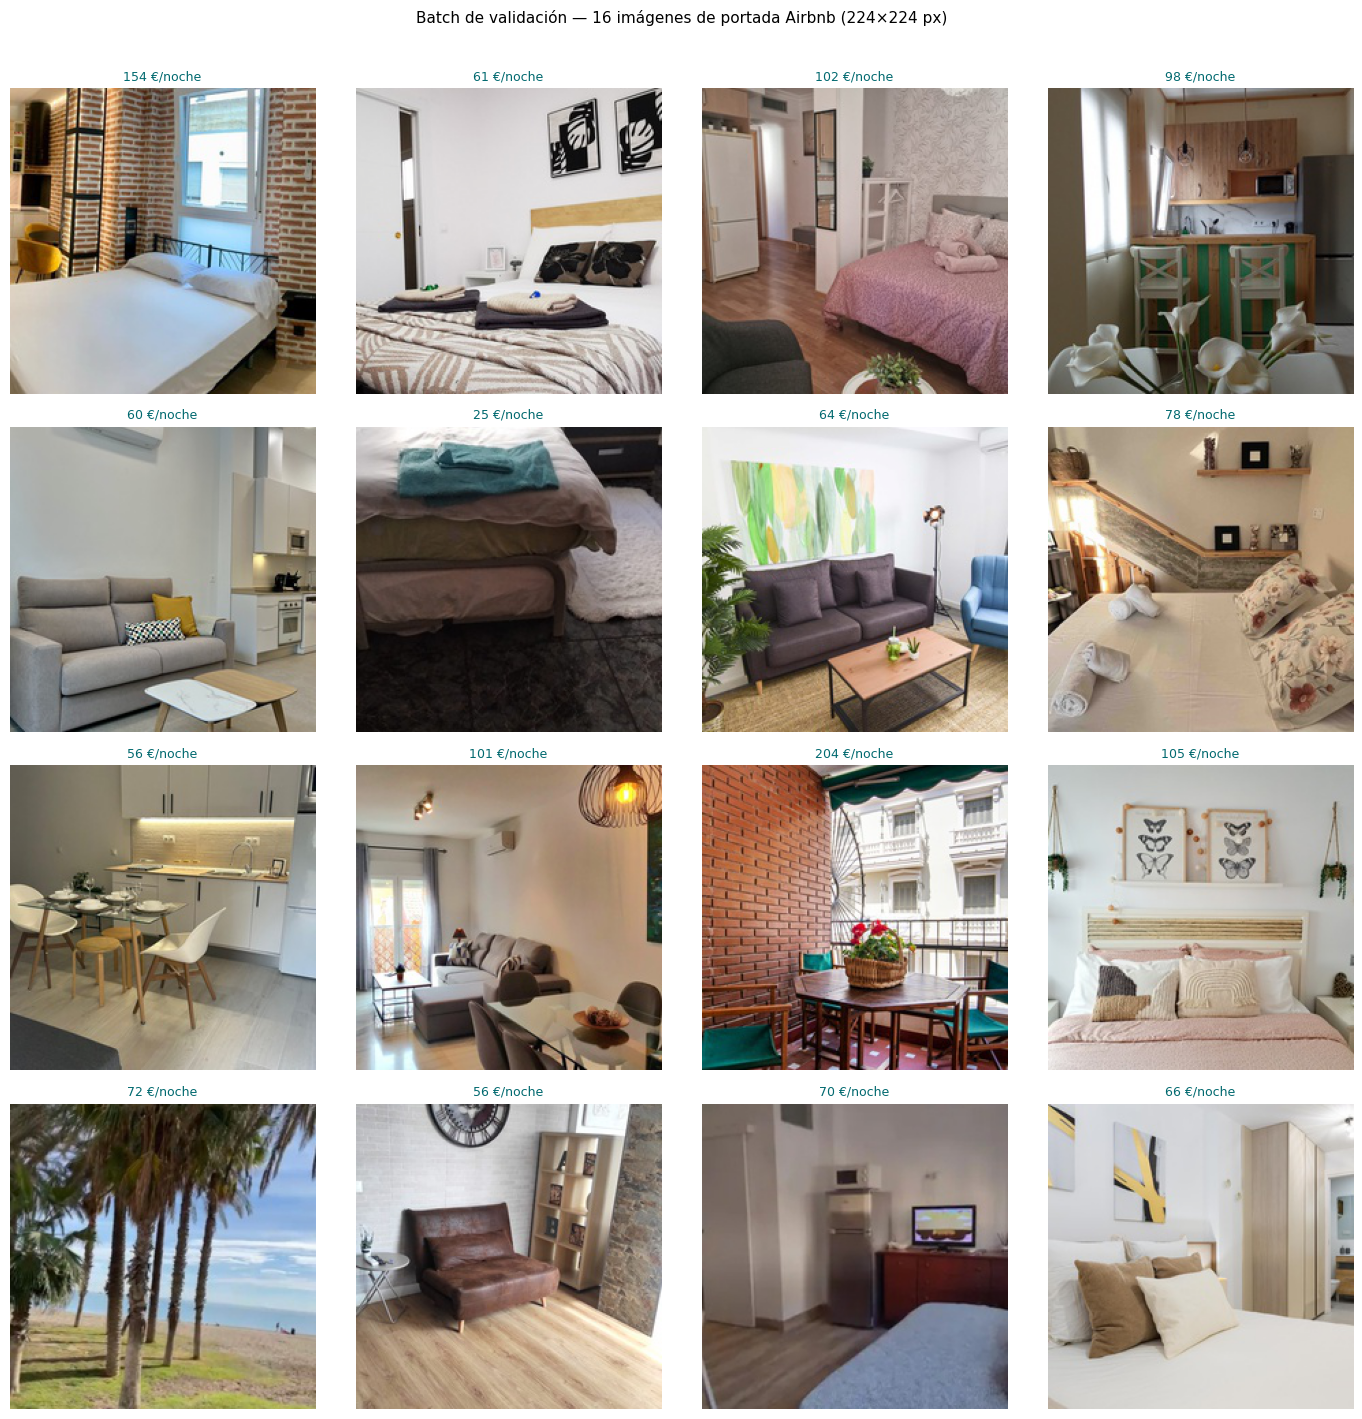


✅ Sección 2 completada. DataLoaders listos para el entrenamiento.
   → Siguiente paso: Sección 3 — Arquitectura Transfer Learning (MobileNetV2)


In [10]:
# ============================================================
# 2.4 — VERIFICACIÓN VISUAL DEL BATCH
# ============================================================

def desnormalizar(tensor):
    """Invierte la normalización ImageNet para visualizar la imagen."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

imagenes, precios = next(iter(loader_val))

print(f"📐 Shape del batch : {imagenes.shape}  → [batch, canales, alto, ancho]")
print(f"💰 Precios del batch (primeros 8): {precios[:8].numpy().round(0)} €/noche")
print(f"   min={precios.min():.0f}€  |  max={precios.max():.0f}€  |  media={precios.mean():.0f}€")

n_mostrar = min(16, len(imagenes))
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle(
    f"Batch de validación — {n_mostrar} imágenes de portada Airbnb (224×224 px)",
    fontsize=11, y=1.01
)

for i, ax in enumerate(axes.flat):
    if i < n_mostrar:
        img_vis = desnormalizar(imagenes[i]).permute(1, 2, 0).numpy()
        ax.imshow(img_vis)
        ax.set_title(f"{precios[i]:.0f} €/noche", fontsize=9, color="#01696f")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\n✅ Sección 2 completada. DataLoaders listos para el entrenamiento.")
print("   → Siguiente paso: Sección 3 — Arquitectura Transfer Learning (MobileNetV2)")

### 3. Arquitectura: Transfer Learning

In [11]:
# ============================================================
# CELDA 3.1 — CARGAR MobileNetV2 PRE-ENTRENADO EN ImageNet
# ============================================================

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

print("=" * 60)
print("  ARQUITECTURA MobileNetV2 ORIGINAL")
print("=" * 60)
print(model)
print("\n")

print("=" * 60)
print("  CABEZA ORIGINAL (model.classifier):")
print("=" * 60)
print(model.classifier)
print(f"\n  → Entrada : 1280 características (salida del backbone)")
print(f"  → Salida  : 1000 clases (ImageNet: perro, gato, coche...)")
# Esta cabeza NO sirve para nuestro problema de regresión.
# La cortaremos y sustituiremos por nuestra propia capa lineal.

  ARQUITECTURA MobileNetV2 ORIGINAL
MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)

In [12]:
# ============================================================
# CELDA 3.2 — CONGELACIÓN (FREEZING) DEL BACKBONE
# ============================================================
# MobileNetV2 se compone de capas convolucionales ya entrenadas
# que saben detectar bordes, texturas, formas y objetos.
# Congelamos parte del backbone para preservar ese conocimiento
# visual y evitar que se destruya durante el entrenamiento.

# Descongelar los últimos N bloques del backbone de MobileNetV2
# features[0..18] — descongelamos desde features[14] en adelante
UNFREEZE_FROM = 14  # bloques 14-18 + classifier

for i, block in enumerate(model.features):
    for param in block.parameters():
        param.requires_grad = (i >= UNFREEZE_FROM)

# classifier ya tiene requires_grad=True
for param in model.classifier.parameters():
    param.requires_grad = True

In [13]:
# ============================================================
# CELDA 3.3 — SUSTITUCIÓN DE LA CABEZA (HEAD)
# ============================================================
# La cabeza original de MobileNetV2 es:
#   Sequential(Dropout(0.2), Linear(1280, 1000))  → 1000 clases ImageNet
#
# La sustituimos por nuestra cabeza de regresión:
#   Sequential(Dropout(0.2), Linear(1280, 1))     → 1 precio €/noche
#
# ✅ Al asignar model.classifier DESPUÉS del freeze, los parámetros
#    de la nueva capa nacen con requires_grad=True por defecto,
#    que es exactamente lo que queremos: solo se entrena la cabeza.

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),    # Regularización: desactiva el 20% de neuronas al azar
    nn.Linear(1280, 1)    # 1280 features → 1 precio (sin activación = regresión lineal)
)

model = model.to(DEVICE)

print("✅ Cabeza sustituida correctamente.")
print(f"\n  Nueva model.classifier:")
print(f"  {model.classifier}")
print(f"\n  Entrada  : 1280 características visuales (backbone frozen)")
print(f"  Salida   : 1 número continuo → precio estimado en €/noche")
print(f"  Activación final: NINGUNA (regresión — salida libre en ℝ)")
print(f"\n  Modelo enviado a: {DEVICE}")

✅ Cabeza sustituida correctamente.

  Nueva model.classifier:
  Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)

  Entrada  : 1280 características visuales (backbone frozen)
  Salida   : 1 número continuo → precio estimado en €/noche
  Activación final: NINGUNA (regresión — salida libre en ℝ)

  Modelo enviado a: cuda


In [14]:
# ============================================================
# CELDA 3.4 — VERIFICAR PARÁMETROS ENTRENABLES
# ============================================================

total_params    = sum(p.numel() for p in model.parameters())
entrenables     = sum(p.numel() for p in model.parameters() if p.requires_grad)
congelados      = total_params - entrenables
pct_entrenables = entrenables / total_params * 100

print("=" * 55)
print("  PARÁMETROS DEL MODELO")
print("=" * 55)
print(f"  Total parámetros       : {total_params:>12,}")
print(f"  ❄️  Congelados (frozen) : {congelados:>12,}  ({100 - pct_entrenables:.2f}%)")
print(f"  🔥 Entrenables         : {entrenables:>12,}  ({pct_entrenables:.2f}%)")
print("=" * 55)
print(f"\n  ✅ Solo se entrena el {pct_entrenables:.2f}% del modelo.")
print(f"     Esto es Transfer Learning: aprovechamos el 99%+ del")
print(f"     conocimiento visual aprendido de 1.2M imágenes de ImageNet")
print(f"     y solo ajustamos la capa final a nuestro problema.")

print(f"\n  Capas con requires_grad=True (entrenables):")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"    ✓ {name:40s} → shape: {list(param.shape)}")

  PARÁMETROS DEL MODELO
  Total parámetros       :    2,225,153
  ❄️  Congelados (frozen) :      542,528  (24.38%)
  🔥 Entrenables         :    1,682,625  (75.62%)

  ✅ Solo se entrena el 75.62% del modelo.
     Esto es Transfer Learning: aprovechamos el 99%+ del
     conocimiento visual aprendido de 1.2M imágenes de ImageNet
     y solo ajustamos la capa final a nuestro problema.

  Capas con requires_grad=True (entrenables):
    ✓ features.14.conv.0.0.weight              → shape: [576, 96, 1, 1]
    ✓ features.14.conv.0.1.weight              → shape: [576]
    ✓ features.14.conv.0.1.bias                → shape: [576]
    ✓ features.14.conv.1.0.weight              → shape: [576, 1, 3, 3]
    ✓ features.14.conv.1.1.weight              → shape: [576]
    ✓ features.14.conv.1.1.bias                → shape: [576]
    ✓ features.14.conv.2.weight                → shape: [160, 576, 1, 1]
    ✓ features.14.conv.3.weight                → shape: [160]
    ✓ features.14.conv.3.bias              

### 4. Entrenamiento del modelo CNN

In [15]:
# ============================================================
# CELDA 4.1 — FUNCIÓN DE PÉRDIDA, OPTIMIZADOR Y SCHEDULER
# ============================================================

criterion = nn.L1Loss()  # MAE — más robusta a outliers de precio que MSE

# Solo pasamos parámetros con requires_grad=True (la nueva cabeza)
optimizer = torch.optim.Adam([
    {'params': model.features[14:].parameters(), 'lr': 1e-5},  # backbone: muy lento
    {'params': model.classifier.parameters(),    'lr': 1e-4},  # cabeza: más rápido
])

# ReduceLROnPlateau: si val_mae no mejora en 'patience' epochs → LR * factor
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=4,
    verbose=True
)

print("✅ Criterio, optimizador y scheduler configurados.")
print(f"\n  Función de pérdida : L1Loss (MAE — error en €/noche)")
print(f"  Optimizador        : Adam (lr={LR})")
print(f"  Scheduler          : ReduceLROnPlateau (patience=4, factor=0.5)")
print(f"\n  Parámetros que se optimizan:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"    🔥 {name:40s} → {list(param.shape)}")

✅ Criterio, optimizador y scheduler configurados.

  Función de pérdida : L1Loss (MAE — error en €/noche)
  Optimizador        : Adam (lr=0.001)
  Scheduler          : ReduceLROnPlateau (patience=4, factor=0.5)

  Parámetros que se optimizan:
    🔥 features.14.conv.0.0.weight              → [576, 96, 1, 1]
    🔥 features.14.conv.0.1.weight              → [576]
    🔥 features.14.conv.0.1.bias                → [576]
    🔥 features.14.conv.1.0.weight              → [576, 1, 3, 3]
    🔥 features.14.conv.1.1.weight              → [576]
    🔥 features.14.conv.1.1.bias                → [576]
    🔥 features.14.conv.2.weight                → [160, 576, 1, 1]
    🔥 features.14.conv.3.weight                → [160]
    🔥 features.14.conv.3.bias                  → [160]
    🔥 features.15.conv.0.0.weight              → [960, 160, 1, 1]
    🔥 features.15.conv.0.1.weight              → [960]
    🔥 features.15.conv.0.1.bias                → [960]
    🔥 features.15.conv.1.0.weight              → [960, 1

c:\Users\david\anaconda3\envs\Airbnb_PIA\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [16]:
# ============================================================
# CELDA 4.2 — BUCLE DE ENTRENAMIENTO CON EARLY STOPPING
# ============================================================
from tqdm import tqdm

EARLY_STOPPING_PATIENCE = 15
best_val_loss      = float("inf")
epochs_sin_mejora  = 0
best_model_weights = None

historial = {
    "epoch":     [],
    "train_mae": [],
    "train_mse": [],
    "val_mae":   [],
    "val_mse":   [],
    "val_rmse":  [],
    "val_r2":    [],
    "lr":        []
}

print("🚀 Iniciando entrenamiento...\n")
print(f"{'Ep':>4} | {'Tr.MSE':>8} | {'Tr.MAE':>8} | {'Va.MSE':>8} | {'Va.MAE':>8} | {'Va.RMSE':>8} | {'R²':>6} | {'LR':>8} | Estado")
print("-" * 105)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── FASE TRAIN ───────────────────────────────────────────
    model.train()
    train_mae_acum = 0.0
    train_mse_acum = 0.0

    for imagenes, precios in tqdm(loader_train,
                                  desc=f"  Epoch {epoch:02d}/{NUM_EPOCHS} [TRAIN]",
                                  leave=False):
        imagenes = imagenes.to(DEVICE)
        precios  = precios.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        predicciones = model(imagenes)

        loss_mae = criterion(predicciones, precios)
        loss_mae.backward()
        optimizer.step()

        n = len(imagenes)
        train_mae_acum += loss_mae.item() * n
        train_mse_acum += ((predicciones - precios) ** 2).sum().item()

    n_train   = len(dataset_train)
    train_mae = train_mae_acum / n_train
    train_mse = train_mse_acum / n_train

    # ── FASE VALIDACIÓN ──────────────────────────────────────
    model.eval()
    val_preds_list  = []
    val_labels_list = []

    with torch.no_grad():
        for imagenes, precios in tqdm(loader_val,
                                      desc=f"  Epoch {epoch:02d}/{NUM_EPOCHS} [VAL]  ",
                                      leave=False):
            imagenes = imagenes.to(DEVICE)
            preds    = model(imagenes).squeeze(1).cpu()
            val_preds_list.append(preds)
            val_labels_list.append(precios)

    val_preds  = torch.cat(val_preds_list).numpy()
    val_labels = torch.cat(val_labels_list).numpy()

    val_mae  = mean_absolute_error(val_labels, val_preds)
    val_mse  = mean_squared_error(val_labels, val_preds)
    val_rmse = np.sqrt(val_mse)
    val_r2   = r2_score(val_labels, val_preds)

    # ── SCHEDULER ────────────────────────────────────────────
    scheduler.step(val_mae)
    lr_actual = optimizer.param_groups[0]["lr"]

    # ── EARLY STOPPING ───────────────────────────────────────
    if val_mae < best_val_loss:
        best_val_loss      = val_mae
        epochs_sin_mejora  = 0
        best_model_weights = {k: v.clone() for k, v in model.state_dict().items()}
        estado = "✅ Mejor"
    else:
        epochs_sin_mejora += 1
        estado = f"⏳ {epochs_sin_mejora}/{EARLY_STOPPING_PATIENCE}"

    # ── REGISTRO ─────────────────────────────────────────────
    historial["epoch"].append(epoch)
    historial["train_mae"].append(train_mae)
    historial["train_mse"].append(train_mse)
    historial["val_mae"].append(val_mae)
    historial["val_mse"].append(val_mse)
    historial["val_rmse"].append(val_rmse)
    historial["val_r2"].append(val_r2)
    historial["lr"].append(lr_actual)

    print(f"{epoch:>4} | {train_mse:>8.1f} | {train_mae:>7.2f}€ | "
            f"{val_mse:>8.1f} | {val_mae:>7.2f}€ | {val_rmse:>7.2f}€ | "
            f"{val_r2:>5.3f} | {lr_actual:>8.2e} | {estado}")

    if epochs_sin_mejora >= EARLY_STOPPING_PATIENCE:
        print(f"\n🛑 Early Stopping en epoch {epoch} — mejor Val MAE: {best_val_loss:.2f}€")
        break

model.load_state_dict(best_model_weights)
print(f"\n✅ Pesos del mejor modelo restaurados (Val MAE = {best_val_loss:.2f}€), Train MAE = {train_mae:.2f}€, Val R² = {val_r2:.3f}")

🚀 Iniciando entrenamiento...

  Ep |   Tr.MSE |   Tr.MAE |   Va.MSE |   Va.MAE |  Va.RMSE |     R² |       LR | Estado
---------------------------------------------------------------------------------------------------------


   1 |  15226.2 |  107.07€ |  14778.3 |  104.13€ |  121.57€ | -2.741 | 1.00e-05 | ✅ Mejor


   2 |  13072.4 |   96.66€ |  12363.7 |   92.03€ |  111.19€ | -2.130 | 1.00e-05 | ✅ Mejor


   3 |  10765.5 |   84.37€ |   9914.8 |   78.09€ |   99.57€ | -1.510 | 1.00e-05 | ✅ Mejor


   4 |   8614.5 |   71.39€ |   8266.5 |   67.70€ |   90.92€ | -1.093 | 1.00e-05 | ✅ Mejor


...

  26 |   2309.1 |   26.30€ |   3539.4 |   38.57€ |   59.49€ | 0.104 | 2.50e-06 | ⏳ 11/15


  27 |   2288.9 |   26.27€ |   3555.1 |   38.67€ |   59.63€ | 0.100 | 2.50e-06 | ⏳ 12/15


  28 |   2262.7 |   26.18€ |   3556.0 |   38.71€ |   59.63€ | 0.100 | 2.50e-06 | ⏳ 13/15


  29 |   2285.8 |   26.20€ |   3574.7 |   38.91€ |   59.79€ | 0.095 | 2.50e-06 | ⏳ 14/15


  30 |   2237.2 |   26.05€ |   3524.5 |   38.74€ |   59.37€ | 0.108 | 1.25e-06 | ⏳ 15/15

🛑 Early Stopping en epoch 30 — mejor Val MAE: 37.51€

✅ Pesos del mejor modelo restaurados (Val MAE = 37.51€), Train MAE = 26.05€, Val R² = 0.108


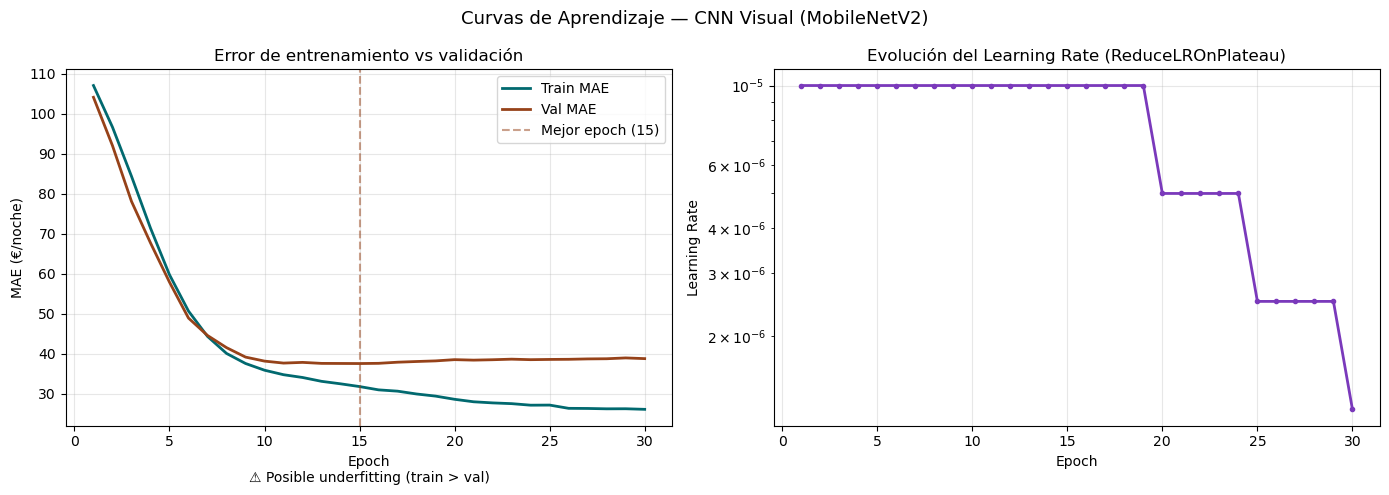


📊 Resumen del entrenamiento:
   Epochs ejecutados   : 30
   Mejor epoch         : 15
   Mejor Val MAE       : 37.51 €/noche


In [17]:
# ============================================================
# CELDA 4.3 — CURVAS DE APRENDIZAJE
# ============================================================

df_hist = pd.DataFrame(historial)

# ✅ FIX: usar "val_mae" en lugar de "val_loss" (que no existe en el historial)
epoch_mejor = df_hist["val_mae"].idxmin() + 1  # epoch base-1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de Aprendizaje — CNN Visual (MobileNetV2)", fontsize=13)

# --- Gráfico 1: Train MAE vs Val MAE ---
ax1.plot(df_hist["epoch"], df_hist["train_mae"],
         label="Train MAE", color="#01696f", linewidth=2)
ax1.plot(df_hist["epoch"], df_hist["val_mae"],
         label="Val MAE",   color="#964219", linewidth=2)
ax1.axvline(epoch_mejor, color="#964219", linestyle="--", alpha=0.5,
            label=f"Mejor epoch ({epoch_mejor})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MAE (€/noche)")
ax1.set_title("Error de entrenamiento vs validación")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ✅ FIX: usar "train_mae" y "val_mae" en lugar de "train_loss" / "val_loss"
gap = df_hist["train_mae"].iloc[-1] - df_hist["val_mae"].iloc[-1]
if abs(gap) < 5:
    diagnostico = "✅ Ajuste correcto (gap train/val pequeño)"
elif gap < -5:
    diagnostico = "⚠️ Posible underfitting (train > val)"
else:
    diagnostico = "⚠️ Posible overfitting (val >> train)"
ax1.set_xlabel(f"Epoch\n{diagnostico}")

# --- Gráfico 2: Evolución del Learning Rate ---
ax2.plot(df_hist["epoch"], df_hist["lr"],
         color="#7a39bb", linewidth=2, marker="o", markersize=3)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Evolución del Learning Rate (ReduceLROnPlateau)")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Resumen del entrenamiento:")
print(f"   Epochs ejecutados   : {len(df_hist)}")
print(f"   Mejor epoch         : {epoch_mejor}")
print(f"   Mejor Val MAE       : {best_val_loss:.2f} €/noche")

  MÉTRICAS FINALES — SET DE VALIDACIÓN
  MAE  (Error Absoluto Medio) : 37.51 €/noche
  RMSE (Error Cuadrático)     : 59.34 €/noche
  R²   (Coef. Determinación)  : 0.1086  (10.9%)

  📌 Interpretación del R²:
  ⚠️  R² = 10.9% → Señal visual débil pero positiva.
     Considera aumentar NUM_EPOCHS o descongelar algunas capas.


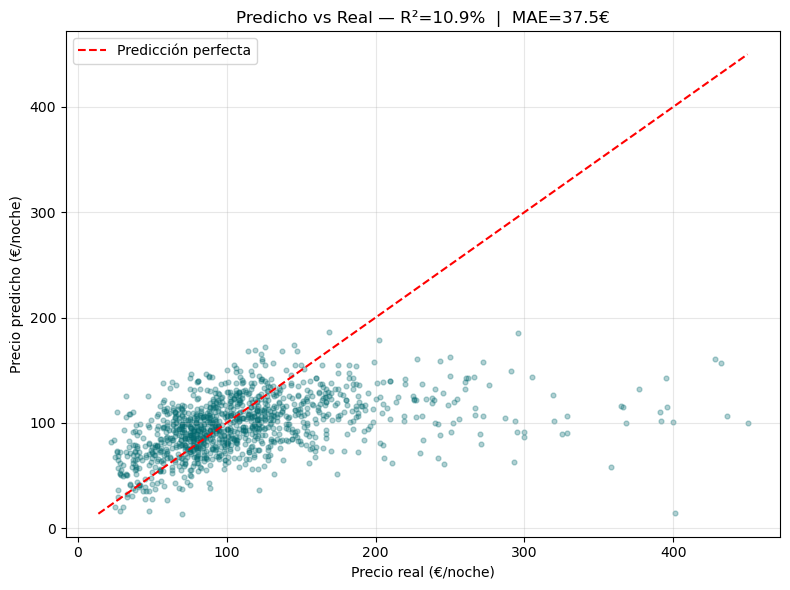

In [18]:
# ============================================================
# CELDA 4.4 — EVALUACIÓN FINAL CON MÉTRICAS
# ============================================================

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imagenes, precios in loader_val:
        imagenes = imagenes.to(DEVICE)
        preds    = model(imagenes).squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(precios.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

mae  = mean_absolute_error(all_labels, all_preds)
rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
r2   = r2_score(all_labels, all_preds)

print("=" * 55)
print("  MÉTRICAS FINALES — SET DE VALIDACIÓN")
print("=" * 55)
print(f"  MAE  (Error Absoluto Medio) : {mae:.2f} €/noche")
print(f"  RMSE (Error Cuadrático)     : {rmse:.2f} €/noche")
print(f"  R²   (Coef. Determinación)  : {r2:.4f}  ({r2*100:.1f}%)")
print("=" * 55)

print("\n  📌 Interpretación del R²:")
if r2 >= 0.30:
    print(f"  🏆 R² = {r2*100:.1f}% → ¡ÉXITO ROTUNDO!")
    print(f"     La CNN ha aprendido a detectar estética visual.")
    print(f"     El vector de características está listo para la fusión.")
elif r2 >= 0.15:
    print(f"  ✅ R² = {r2*100:.1f}% → Resultado CORRECTO.")
    print(f"     La CNN extrae señal visual útil del precio.")
    print(f"     Recuerda: una foto sola no sabe si el piso está en el centro.")
elif r2 >= 0.0:
    print(f"  ⚠️  R² = {r2*100:.1f}% → Señal visual débil pero positiva.")
    print(f"     Considera aumentar NUM_EPOCHS o descongelar algunas capas.")
else:
    print(f"  ❌ R² = {r2*100:.1f}% → El modelo no ha aprendido.")
    print(f"     Revisar dataset (¿imágenes corruptas?) o reducir LR.")

# --- Scatter: Predicho vs Real ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(all_labels, all_preds, alpha=0.3, s=12, color="#01696f")
lims = [min(all_labels.min(), all_preds.min()),
        max(all_labels.max(), all_preds.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
ax.set_xlabel("Precio real (€/noche)")
ax.set_ylabel("Precio predicho (€/noche)")
ax.set_title(f"Predicho vs Real — R²={r2*100:.1f}%  |  MAE={mae:.1f}€")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Guardado del modelo y preparación para la fusión multimodal

In [19]:
# ============================================================
# CELDA 5.1 — GUARDAR LOS PESOS DEL MODELO (cnn_model.pt)
# ============================================================

ruta_modelo = MODEL_DIR / "cnn_model_MobileNetV2.pt"

torch.save(model.state_dict(), ruta_modelo)

print("=" * 55)
print("  MODELO GUARDADO")
print("=" * 55)
print(f"  📁 Ruta : {ruta_modelo}")
print(f"  📦 Tamaño : {ruta_modelo.stat().st_size / 1e6:.1f} MB")
print(f"\n  Contenido guardado: state_dict()")
print(f"  → Todos los pesos del backbone (frozen)")
print(f"  → Los pesos entrenados de model.classifier")
print(f"\n  Para recargar el modelo completo en el futuro:")
print(f"    model = models.mobilenet_v2()")
print(f"    model.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(1280, 1))")
print(f"    model.load_state_dict(torch.load('models/cnn_model.pt'))")

  MODELO GUARDADO
  📁 Ruta : ..\models\cnn_model_MobileNetV2.pt
  📦 Tamaño : 9.1 MB

  Contenido guardado: state_dict()
  → Todos los pesos del backbone (frozen)
  → Los pesos entrenados de model.classifier

  Para recargar el modelo completo en el futuro:
    model = models.mobilenet_v2()
    model.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(1280, 1))
    model.load_state_dict(torch.load('models/cnn_model.pt'))


In [20]:
# ============================================================
# CELDA 5.2 — CREAR EL FEATURE EXTRACTOR VISUAL
# ============================================================


# Construir el extractor: cargamos los pesos guardados y
# reemplazamos la cabeza por Identity (pasa el tensor sin tocarlo)
feature_extractor = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)
feature_extractor.classifier = nn.Identity()  # Eliminar cabeza → salida = 1280 features

# Cargar los pesos entrenados del backbone (la cabeza Identity no tiene pesos)
state_dict_entrenado = torch.load(ruta_modelo, map_location=DEVICE)

# Filtrar solo los pesos del backbone (excluir classifier.*)
state_dict_backbone = {
    k: v for k, v in state_dict_entrenado.items()
    if not k.startswith("classifier")
}
feature_extractor.load_state_dict(state_dict_backbone, strict=False)

feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()  # Siempre en modo eval: no Dropout, no BatchNorm en train

print("✅ Feature Extractor construido correctamente.")
print(f"\n  Backbone     : MobileNetV2 (pesos del entrenamiento CNN cargados)")
print(f"  Cabeza       : nn.Identity() — eliminada")
print(f"  Modo         : eval() — determinista, sin dropout activo")
print(f"  Dispositivo  : {DEVICE}")

✅ Feature Extractor construido correctamente.

  Backbone     : MobileNetV2 (pesos del entrenamiento CNN cargados)
  Cabeza       : nn.Identity() — eliminada
  Modo         : eval() — determinista, sin dropout activo
  Dispositivo  : cuda


C:\Users\david\AppData\Local\Temp\ipykernel_31096\3052985066.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict_entrenado = torch.load(ruta_modelo, map_location

  TEST DEL FEATURE EXTRACTOR
  Input  — batch de imágenes : torch.Size([32, 3, 224, 224])
                                 [batch, 3, 224, 224]

  Output — vector de features : torch.Size([32, 1280])
                                 [batch, 1280]

  ✅ Shape verificado: cada imagen → vector de 1280 números

  Estadísticas del vector (primer apartamento):
    Min   : 0.3476
    Max   : 1.0794
    Media : 0.6079
    Std   : 0.0852


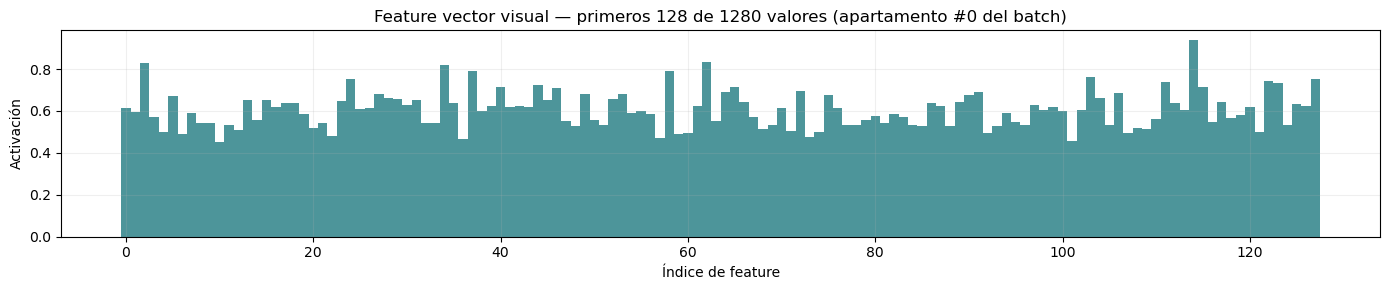


  🎯 FASE 3 COMPLETADA
  Archivos generados:
    models/cnn_model.pt       — pesos completos del modelo

  En la FASE FINAL (Fusión Multimodal):
    1. Cargar feature_extractor desde cnn_model.pt
    2. Para cada apartamento: imagen → vector [1280]
    3. Concatenar con vector tabular [N features]
    4. Pasar por capa densa final → precio optimizado €


In [21]:
# ============================================================
# CELDA 5.3 — TEST DEL FEATURE EXTRACTOR
# ============================================================

# Extraer un batch del loader de validación para probar
imagenes_test, precios_test = next(iter(loader_val))
imagenes_test = imagenes_test.to(DEVICE)

with torch.no_grad():
    vector_features = feature_extractor(imagenes_test)

print("=" * 55)
print("  TEST DEL FEATURE EXTRACTOR")
print("=" * 55)
print(f"  Input  — batch de imágenes : {imagenes_test.shape}")
print(f"                                 [batch, 3, 224, 224]")
print(f"\n  Output — vector de features : {vector_features.shape}")
print(f"                                 [batch, 1280]")
print("=" * 55)

# Verificar que la forma es la esperada
assert vector_features.shape == (imagenes_test.shape[0], 1280), \
    f"❌ Shape inesperado: {vector_features.shape}"

print(f"\n  ✅ Shape verificado: cada imagen → vector de 1280 números")
print(f"\n  Estadísticas del vector (primer apartamento):")
v = vector_features[0].cpu().numpy()
print(f"    Min   : {v.min():.4f}")
print(f"    Max   : {v.max():.4f}")
print(f"    Media : {v.mean():.4f}")
print(f"    Std   : {v.std():.4f}")

# --- Visualizar los primeros 128 valores del vector del primer apt ---
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(128), v[:128], color="#01696f", alpha=0.7, width=1.0)
ax.set_title("Feature vector visual — primeros 128 de 1280 valores (apartamento #0 del batch)")
ax.set_xlabel("Índice de feature")
ax.set_ylabel("Activación")
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\n{'=' * 55}")
print(f"  🎯 FASE 3 COMPLETADA")
print(f"{'=' * 55}")
print(f"  Archivos generados:")
print(f"    models/cnn_model.pt       — pesos completos del modelo")
print(f"\n  En la FASE FINAL (Fusión Multimodal):")
print(f"    1. Cargar feature_extractor desde cnn_model.pt")
print(f"    2. Para cada apartamento: imagen → vector [1280]")
print(f"    3. Concatenar con vector tabular [N features]")
print(f"    4. Pasar por capa densa final → precio optimizado €")